# Imports and load data

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [31]:
X = pd.read_csv("../data/03_selected/clustering_features.csv")

In [32]:
X_pca = pd.read_csv("../data/03_selected/pca_space.csv")

# Dendrogram

Agglomerative approach with ward  and complete linkage

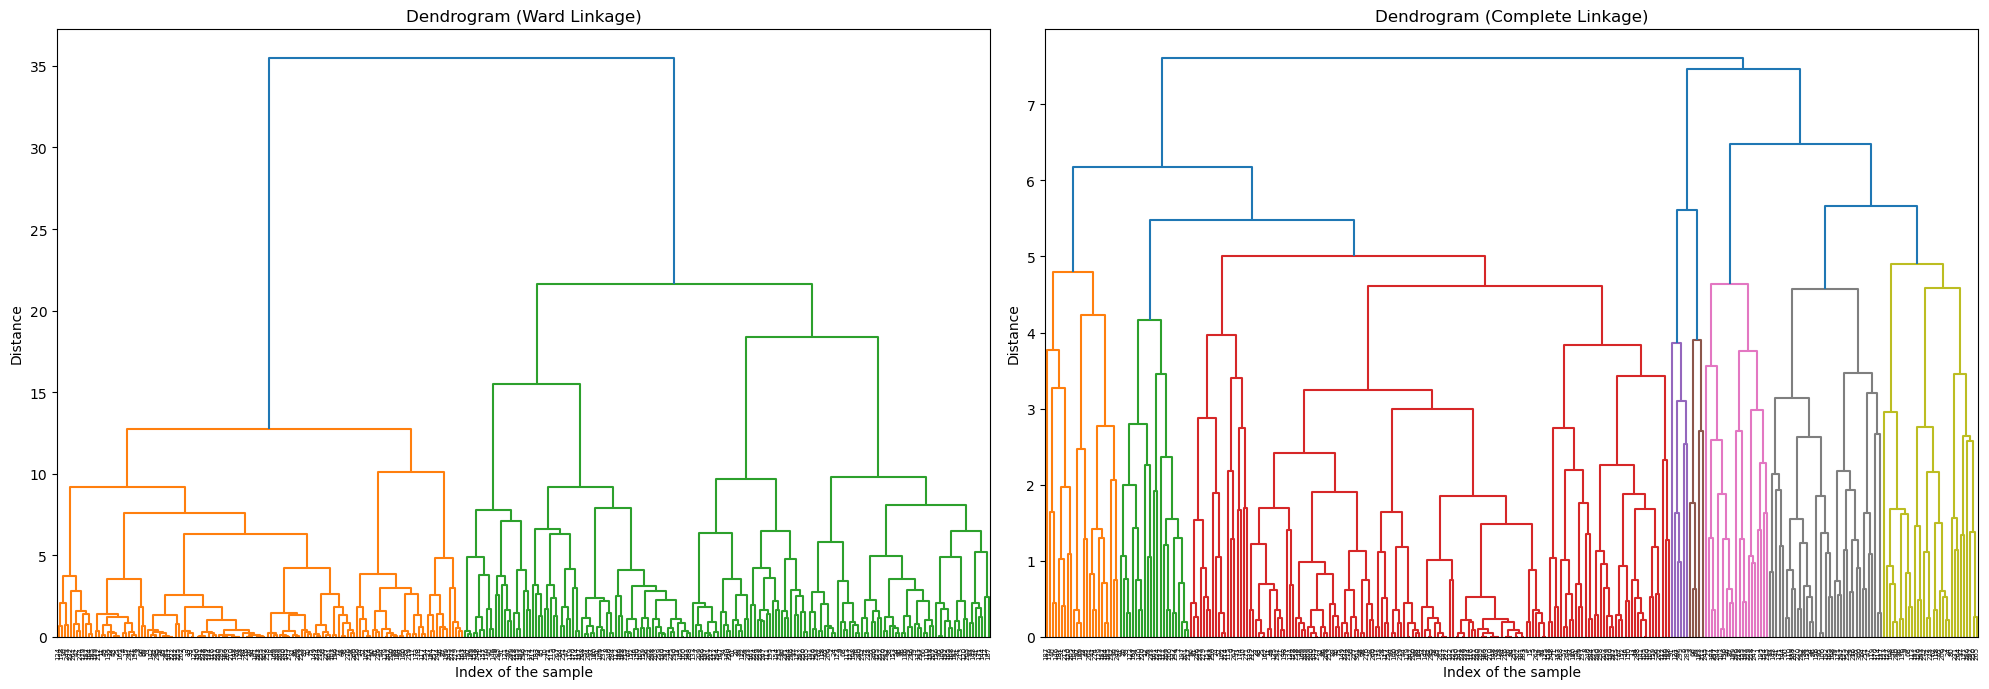

In [33]:
# Compute linkage matrix
Z_ward = linkage(X, method='ward')
Z_complete = linkage(X, method='complete')

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Ward dendrogram
dendrogram(Z_ward, ax=axes[0])
axes[0].set_title("Dendrogram (Ward Linkage)")
axes[0].set_xlabel("Index of the sample")
axes[0].set_ylabel("Distance")

# Complete dendrogram
dendrogram(Z_complete, ax=axes[1])
axes[1].set_title("Dendrogram (Complete Linkage)")
axes[1].set_xlabel("Index of the sample")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()

# Decision: number of clusters

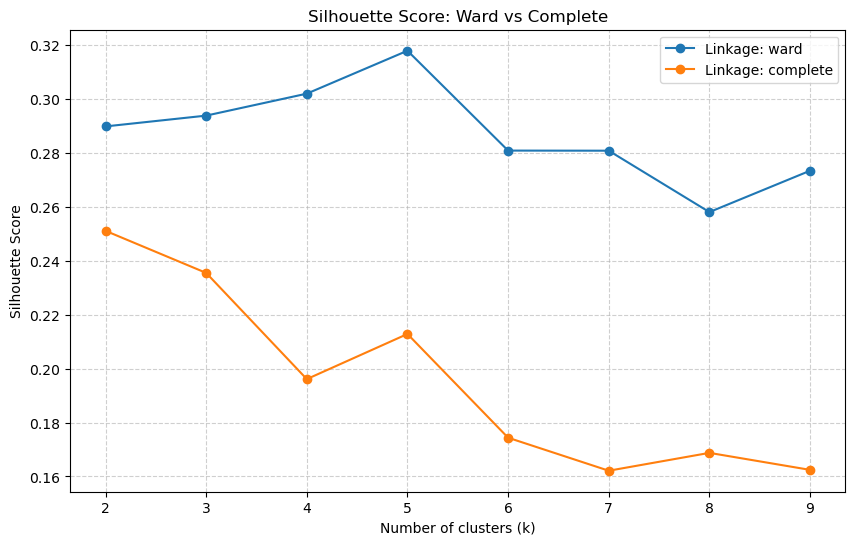

In [34]:
# Define ranges and type of linkages
k_values = range(2, 10)
linkages = ['ward', 'complete']
results = {}

# iterate in every linkage type
for link in linkages:
    scores = []
    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = model.fit_predict(X)
        
        score = silhouette_score(X, labels)
        scores.append(score)
    results[link] = scores

plt.figure(figsize=(10, 6))

for link, scores in results.items():
    plt.plot(k_values, scores, marker='o', label=f'Linkage: {link}')

plt.title("Silhouette Score: Ward vs Complete")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Apply clustering

In [35]:
hc_best = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hc_labels = hc_best.fit_predict(X)

In [36]:
X_hc = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_hc['HC_Cluster'] = hc_labels

X_hc.head()

,PC1,PC2,HC_Cluster
0,-1.561300,-2.075091,0
1,-3.067305,-1.923260,0
2,-3.749194,-0.046765,0
3,1.473170,0.812834,1
4,2.635836,-1.300294,1


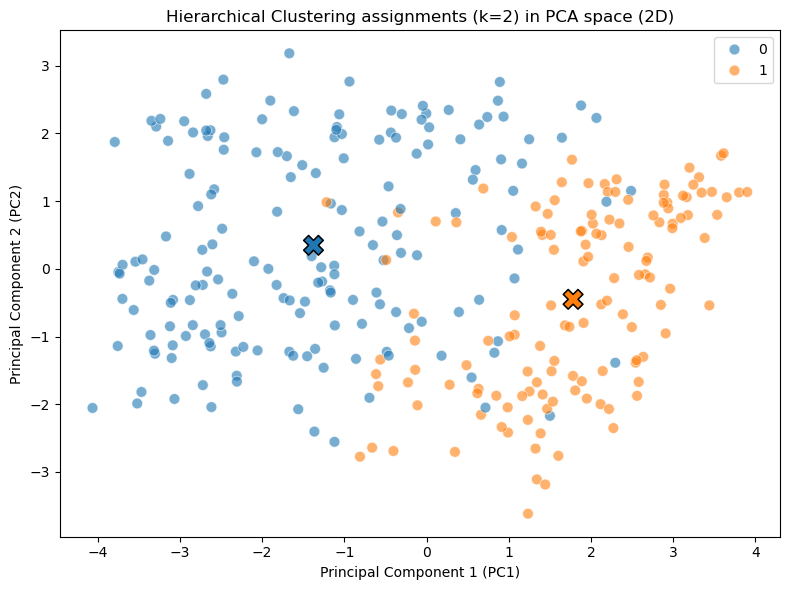

In [44]:
plt.figure(figsize=(8, 6))

# Puntos (datos)
sns.scatterplot(
    data=X_hc,
    x="PC1",
    y="PC2",
    hue="HC_Cluster",
    palette='tab10',
    s=60,
    alpha=0.6
)

# Centroides (media de cada cluster)
centroids_pca = X_hc.groupby('HC_Cluster')[['PC1', 'PC2']].mean()

sns.scatterplot(
    data=centroids_pca,
    x="PC1",
    y="PC2",
    hue='HC_Cluster',
    palette='tab10',
    marker="X",
    s=200,
    edgecolor='black',
    legend=False
)

plt.title(f"Hierarchical Clustering assignments (k={2}) in PCA space (2D)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.tight_layout()
plt.show()

# Performance mtrics

In [38]:
y = pd.read_csv("../data/03_selected/clustering_features_with_target.csv")['target']
truth_hc = pd.DataFrame({
    'cluster': X_hc['HC_Cluster'],
    'target': y
})

In [39]:
ari_hc = adjusted_rand_score(truth_hc['cluster'], truth_hc['target'])
print(f"Adjusted Rand Index (ARI) for HC: {ari_hc:.4f}")

Adjusted Rand Index (ARI) for HC: 0.2870


In [40]:
final_score = silhouette_score(X, hc_labels)
print(f"Final silhouette score: {final_score:.4f}")

Final silhouette score: 0.2898


In [41]:
cluster_profile = pd.DataFrame(X).copy()
cluster_profile['cluster'] = hc_labels

cluster_profile.groupby('cluster').mean()

,thalach,oldpeak,ca,cp_4,is_exang,thal_3,thal_7
cluster,,,,,,,
0,-0.333876,0.329579,0.273106,0.406729,0.537750,-0.691974,0.612230
1,0.432521,-0.426954,-0.353797,-0.526899,-0.696631,0.896421,-0.793116


In [42]:
cm = confusion_matrix(truth_hc['target'], truth_hc['cluster'])
cm

array([[ 51, 113],
       [120,  19]])

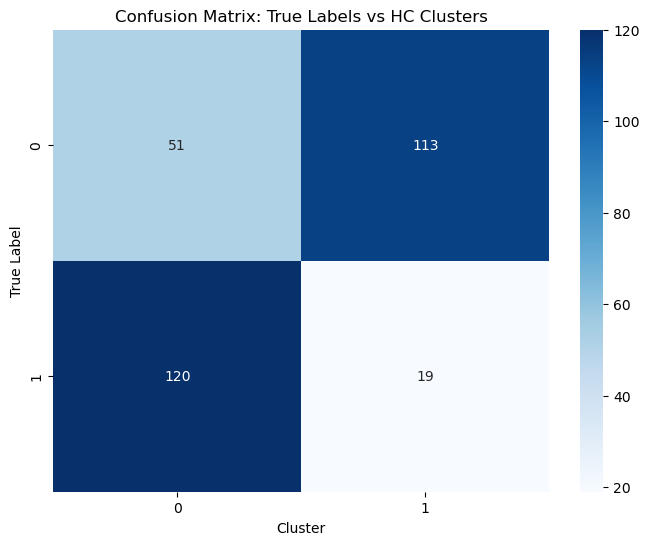

In [43]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix: True Labels vs HC Clusters")
plt.xlabel("Cluster")
plt.ylabel("True Label")

plt.show()